# Earshot — NLP Pipeline for Spoken-Audio Transcripts

**Semantic search, retrieval-augmented Q&A, and summarization over meeting / lecture / podcast / interview transcripts.**

This notebook is the NLP core of the project. It builds, compares, and evaluates two retrieval approaches over a corpus of real captured + sample sessions:

1. **TF-IDF** — a classic sparse bag-of-words baseline (scikit-learn).
2. **Dense embeddings** — `all-MiniLM-L6-v2` sentence-transformers (the *same* model the live app runs on-device).

It then adds embedding-based **extractive summarization**, **keyphrase extraction**, an **embedding-space visualization**, and a **RAG retrieval** walkthrough.

> Pipeline: `transcript → preprocess → vectorize (TF-IDF / MiniLM) → cosine-similarity retrieval → rank → summarize`.

## 0 · Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))  # make the `nlp` package importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nlp import data, preprocess, vectorizers, embeddings, search, summarize, keywords, evaluate

sns.set_theme(style='whitegrid')
preprocess.ensure_nltk()  # download tokenizer / stopwords / wordnet on first run
pd.set_option('display.max_colwidth', 80)
print('Setup complete.')

Setup complete.


## 1 · Load & explore the corpus

Each row is one session with its full transcript and structured summary. Sessions are tagged `captured` (real recordings) or `sample` (added for demonstration), and by `mode`.

In [2]:
df = data.load_sessions()
print(f'{len(df)} sessions')
df[['title', 'mode', 'source', 'wordCount']]

11 sessions


,title,mode,source,wordCount
0,Stacks and Queues,lecture,captured,150
1,Intro to Neural Networks,lecture,captured,95
2,Q3 Roadmap Sync,meeting,captured,80
3,Checkout Redesign — Design Review,meeting,sample,96
4,Sprint 24 Retrospective,meeting,sample,95
5,Intro to Probability — Bayes' Theorem,lecture,sample,112
6,Biology 101 — Photosynthesis,lecture,sample,110
7,Deep Dive Podcast — The Future of AGI,podcast,sample,116
8,Founder Hour — Productivity and Deep Work,podcast,sample,113
9,Backend Engineer — Technical Screen,interview,sample,106


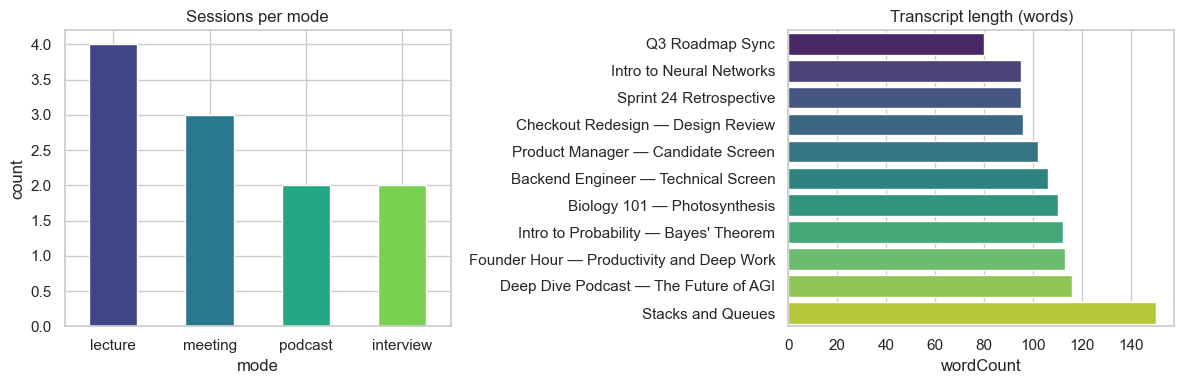

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['mode'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('viridis', df['mode'].nunique()))
axes[0].set_title('Sessions per mode'); axes[0].set_ylabel('count'); axes[0].tick_params(axis='x', rotation=0)
sns.barplot(data=df.sort_values('wordCount'), x='wordCount', y='title', ax=axes[1], palette='viridis')
axes[1].set_title('Transcript length (words)'); axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

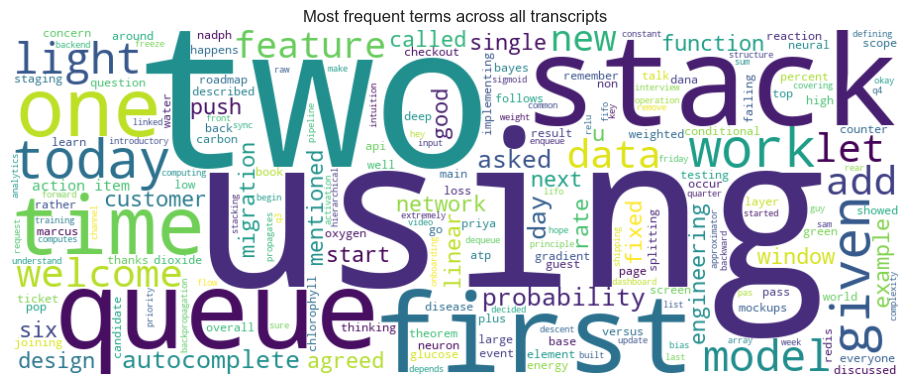

In [4]:
from wordcloud import WordCloud
corpus_text = ' '.join(preprocess.preprocess(t) for t in df['transcript'])
wc = WordCloud(width=900, height=350, background_color='white', colormap='viridis').generate(corpus_text)
plt.figure(figsize=(12, 4.5)); plt.imshow(wc, interpolation='bilinear'); plt.axis('off')
plt.title('Most frequent terms across all transcripts'); plt.show()

## 2 · Text preprocessing

Classic NLP cleanup for the TF-IDF path: lowercase → strip punctuation/markdown → tokenize → drop stopwords → lemmatize. (Dense embeddings deliberately use the *raw* text — they model context directly.)

In [5]:
sample = df.loc[df.title == 'Stacks and Queues', 'transcript'].iloc[0]
print('RAW:\n', sample[:240], '...\n')
print('TOKENS:\n', preprocess.tokenize(sample)[:25], '...')

RAW:
 Hey, welcome back to the channel. I hope you guys are doing extremely well. This will be an introductory video about stacks and queues. I'll be covering what is a stack, what is a queue, and then implementing stack and queue using arrays an ...

TOKENS:
 ['hey', 'welcome', 'back', 'channel', 'hope', 'guy', 'extremely', 'well', 'introductory', 'video', 'stack', 'queue', 'covering', 'stack', 'queue', 'implementing', 'stack', 'queue', 'using', 'array', 'using', 'linked', 'list', 'stack', 'linear'] ...


## 3 · TF-IDF baseline

Turn each session into a sparse TF-IDF vector (unigrams + bigrams). The most heavily weighted terms per session double as interpretable keyphrases.

In [6]:
tfidf_vec, tfidf_matrix = vectorizers.build_tfidf(df['document'].tolist())
print('TF-IDF matrix shape (sessions x vocab):', tfidf_matrix.shape)
for title in ['Stacks and Queues', 'Biology 101 — Photosynthesis']:
    row = df.index[df.title == title][0]
    terms = ', '.join(t for t, _ in vectorizers.top_terms(tfidf_vec, tfidf_matrix, row, n=6))
    print(f'\n{title}:\n  {terms}')

TF-IDF matrix shape (sessions x vocab): (11, 1716)

Stacks and Queues:
  stack, queue, stack queue, structure, pop, operation

Biology 101 — Photosynthesis:
  light, nadph, atp nadph, atp, glucose, oxygen


## 4 · Dense sentence embeddings

Encode each session with `all-MiniLM-L6-v2` into a normalized 384-dim vector — the same model and dimensionality the production app uses on-device.

In [7]:
doc_embeddings = embeddings.embed(df['document'].tolist())
print('Embedding matrix shape (sessions x dims):', doc_embeddings.shape)
print('L2 norm of first row (should be ~1.0):', np.linalg.norm(doc_embeddings[0]).round(4))

Embedding matrix shape (sessions x dims): (11, 384)
L2 norm of first row (should be ~1.0): 1.0


## 5 · Semantic search: TF-IDF vs. embeddings

Both indexes expose the same `search(query, k)` API. Note how dense retrieval handles vocabulary mismatch — a query needn't share exact words with the transcript.

In [8]:
metas = df[['sessionId', 'title', 'mode']].to_dict('records')
docs = df['document'].tolist()
idx_tfidf = search.SemanticIndex(docs, metas, method='tfidf')
idx_dense = search.SemanticIndex(docs, metas, method='dense')

def show(query, k=3):
    print(f'QUERY: {query!r}\n')
    for name, idx in [('TF-IDF', idx_tfidf), ('Dense', idx_dense)]:
        print(f'  [{name}]')
        for r in idx.search(query, k=k):
            print(f'    {r.score:.3f}  {r.meta["title"]}')
        print()

show('how do plants turn sunlight into food')

QUERY: 'how do plants turn sunlight into food'

  [TF-IDF]
    0.097  Biology 101 — Photosynthesis
    0.000  Product Manager — Candidate Screen
    0.000  Backend Engineer — Technical Screen

  [Dense]
    0.532  Biology 101 — Photosynthesis
    0.053  Intro to Neural Networks
    0.045  Founder Hour — Productivity and Deep Work



In [9]:
show('tips for staying focused and getting deep work done')

QUERY: 'tips for staying focused and getting deep work done'

  [TF-IDF]
    0.196  Founder Hour — Productivity and Deep Work
    0.049  Deep Dive Podcast — The Future of AGI
    0.025  Product Manager — Candidate Screen

  [Dense]


    0.510  Founder Hour — Productivity and Deep Work
    0.239  Deep Dive Podcast — The Future of AGI
    0.220  Sprint 24 Retrospective



## 6 · Evaluation — TF-IDF vs. dense embeddings

Against a hand-labeled set of **paraphrased** `query → expected session` pairs (queries that deliberately avoid the transcript's exact words), we measure **Hit@1**, **Recall@k**, and **MRR** (mean reciprocal rank). This is where dense embeddings should pull ahead: TF-IDF can only match shared terms, while embeddings match *meaning*.

In [10]:
k = 3
m_tfidf, by_q_tfidf = evaluate.evaluate_index(idx_tfidf, k=k)
m_dense, by_q_dense = evaluate.evaluate_index(idx_dense, k=k)
comparison = pd.DataFrame([m_tfidf, m_dense], index=['TF-IDF', 'Dense (MiniLM)'])
comparison

,queries,hit@1,recall@3,MRR
TF-IDF,11,0.545455,0.727273,0.606061
Dense (MiniLM),11,0.909091,1.000000,0.954545


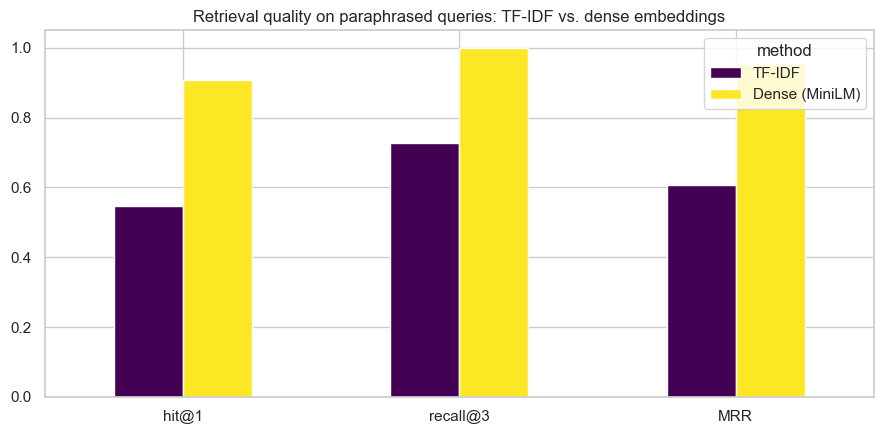

In [11]:
ax = comparison[['hit@1', f'recall@{k}', 'MRR']].T.plot(kind='bar', figsize=(9, 4.5), colormap='viridis')
ax.set_title('Retrieval quality on paraphrased queries: TF-IDF vs. dense embeddings'); ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=0); ax.legend(title='method'); plt.tight_layout(); plt.show()

Per-query view — the rows where TF-IDF's `top_hit` is wrong but dense is right are exactly the paraphrases with no shared vocabulary (e.g. *"throttling requests"* → the API rate-limiter interview). TF-IDF occasionally wins when the paraphrase still shares a rare keyword.

In [12]:
merged = by_q_tfidf[['query', 'expected', 'top_hit', 'hit@1']].rename(columns={'top_hit': 'tfidf_hit', 'hit@1': 'tfidf@1'})
merged['dense_hit'] = by_q_dense['top_hit']; merged['dense@1'] = by_q_dense['hit@1']
merged[['query', 'expected', 'tfidf_hit', 'tfidf@1', 'dense_hit', 'dense@1']]

,query,expected,tfidf_hit,tfidf@1,dense_hit,dense@1
0,the container that pops the most recently added item,real-stacks,real-stacks,True,real-stacks,True
1,teaching machines to recognize patterns by adjusting weights,real-neural-nets,real-neural-nets,True,real-neural-nets,True
2,what did the new-hire onboarding discussion decide,real-q3-roadmap,real-q3-roadmap,True,sample-sprint-retro,False
3,improving the online shopping purchase flow,sample-design-review,real-q3-roadmap,False,sample-design-review,True
4,the team looks back at the last development cycle,sample-sprint-retro,sample-photosynthesis,False,sample-sprint-retro,True
5,reasoning about uncertainty and reversing conditional odds,sample-probability,sample-probability,True,sample-probability,True
6,the chemistry plants use to grow from light,sample-photosynthesis,sample-photosynthesis,True,sample-photosynthesis,True
7,debate on whether bigger models reach human-level intelligence,sample-podcast-agi,sample-podcast-agi,True,sample-podcast-agi,True
8,guarding your concentration from distractions,sample-podcast-productivity,sample-interview-pm,False,sample-podcast-productivity,True
9,a talk about throttling requests to a web service,sample-interview-backend,real-q3-roadmap,False,sample-interview-backend,True


## 7 · Visualizing the embedding space

Projecting the 384-dim session vectors to 2-D with PCA shows that sessions of the same **mode** and topic cluster together — direct evidence the embeddings capture meaning.

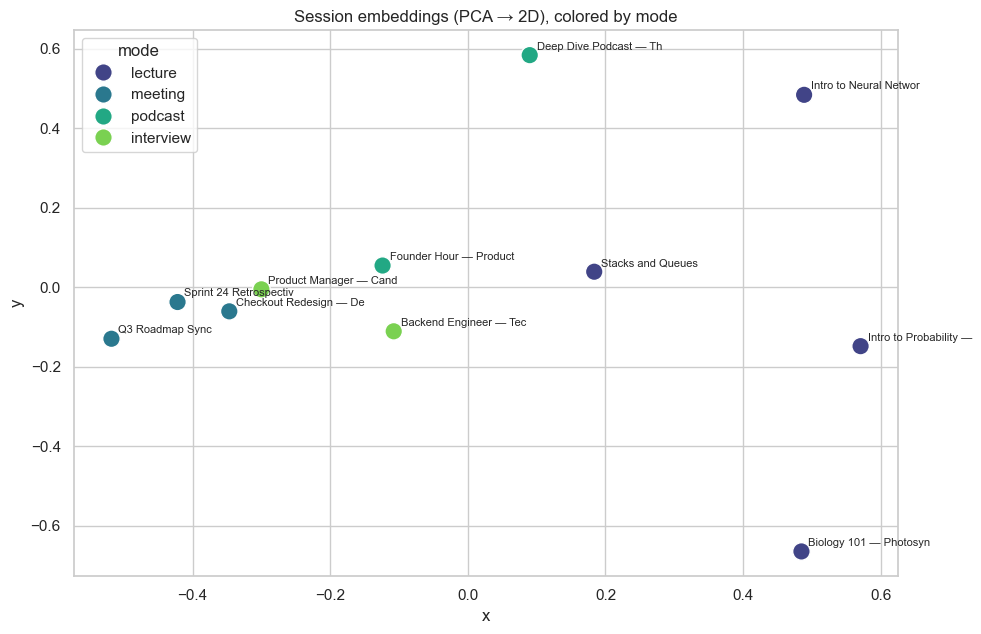

In [13]:
from sklearn.decomposition import PCA
coords = PCA(n_components=2, random_state=0).fit_transform(doc_embeddings)
viz = df.copy(); viz['x'], viz['y'] = coords[:, 0], coords[:, 1]
plt.figure(figsize=(10, 6.5))
sns.scatterplot(data=viz, x='x', y='y', hue='mode', s=160, palette='viridis')
for _, r in viz.iterrows():
    plt.annotate(r['title'][:22], (r['x'], r['y']), fontsize=8, xytext=(5, 4), textcoords='offset points')
plt.title('Session embeddings (PCA → 2D), colored by mode'); plt.tight_layout(); plt.show()

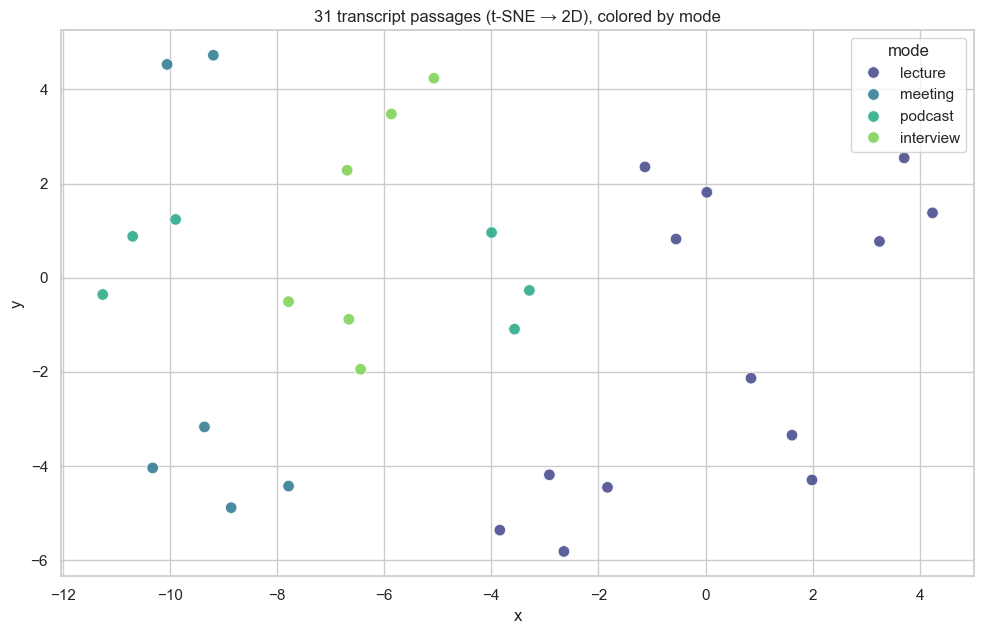

In [14]:
# Finer-grained view: project transcript *passages* with t-SNE.
passages = data.build_passages(df)
p_emb = embeddings.embed(passages['passage'].tolist())
from sklearn.manifold import TSNE
perp = max(2, min(15, len(passages) - 1))
p_coords = TSNE(n_components=2, perplexity=perp, init='pca', random_state=0).fit_transform(p_emb)
passages = passages.assign(x=p_coords[:, 0], y=p_coords[:, 1])
plt.figure(figsize=(10, 6.5))
sns.scatterplot(data=passages, x='x', y='y', hue='mode', s=70, palette='viridis', alpha=0.85)
plt.title(f'{len(passages)} transcript passages (t-SNE → 2D), colored by mode'); plt.tight_layout(); plt.show()

## 8 · Extractive summarization (embedding TextRank)

A fully-local summarizer: embed each sentence, build a cosine-similarity graph, and rank sentences by PageRank centrality. Complements the app's abstractive LLM summaries — no API key.

In [15]:
row = df[df.title == 'Q3 Roadmap Sync'].iloc[0]
print('EXTRACTIVE (TextRank over sentence embeddings):\n')
for s in summarize.textrank_summary(row['transcript'], num_sentences=3):
    print(' •', s)

EXTRACTIVE (TextRank over sentence embeddings):



 • Okay let's get started with the Q3 roadmap sync.
 • Action item for Sam is to scope the migration by next Friday.
 • Next steps: Priya shares mockups Monday, Marcus drafts the API contract.


## 9 · Keyphrase extraction

Top TF-IDF terms per session — a quick auto-tagging signal.

In [16]:
kw = keywords.extract_keywords(df['document'].tolist(), n=6)
for title, terms in zip(df['title'], kw):
    print(f'{title:42s} →  ' + ', '.join(t for t, _ in terms))

Stacks and Queues                          →  stack, queue, stack queue, structure, pop, operation
Intro to Neural Networks                   →  network, gradient, function, neuron, non, neural network
Q3 Roadmap Sync                            →  q3, dashboard, pipeline, q4, analytics, analytics dashboard
Checkout Redesign — Design Review          →  autocomplete, checkout, single page, page, single, address
Sprint 24 Retrospective                    →  ticket, staging, sprint, add health, check alert, underestimated
Intro to Probability — Bayes' Theorem      →  probability, given, theorem, bayes, bayes theorem, conditional
Biology 101 — Photosynthesis               →  light, nadph, atp nadph, atp, glucose, oxygen
Deep Dive Podcast — The Future of AGI      →  model, world, memory, world model, reasoning, interpolation
Founder Hour — Productivity and Deep Work  →  deep work, deep, meeting, day, work, advice
Backend Engineer — Technical Screen        →  window, redis, counter, technical

## 10 · Retrieval-augmented generation (RAG) walkthrough

The retrieval half of the app's *Ask AI* feature. We chunk transcripts into passages, embed them, retrieve the passages most similar to a question, and assemble the **context** that would be handed to the LLM for a grounded, cited answer.

In [17]:
passage_index = search.SemanticIndex(
    passages['passage'].tolist(),
    passages[['sessionId', 'title', 'mode', 'chunk_id']].to_dict('records'),
    method='dense',
)
question = 'what algorithm did the candidate suggest for rate limiting?'
print(f'QUESTION: {question}\n\nRetrieved context:\n')
for r in passage_index.search(question, k=3):
    print(f'[{r.score:.3f}] from "{r.meta["title"]}":')
    print('   ', r.text[:220], '...\n')

QUESTION: what algorithm did the candidate suggest for rate limiting?

Retrieved context:

[0.549] from "Backend Engineer — Technical Screen":
    Thanks for joining the technical screen. To start, can you walk me through how you would design a rate limiter for an API. The candidate proposed a token bucket algorithm and explained the trade-offs versus a fixed windo ...

[0.325] from "Intro to Probability — Bayes' Theorem":
    equals P of B given A times P of A divided by P of B. The classic example is medical testing. Even with a highly accurate test, if a disease is rare, the probability you actually have it given a positive result can be su ...

[0.272] from "Intro to Probability — Bayes' Theorem":
    be surprisingly low because of the base rate. This is called the base rate fallacy. For the assignment, work through the disease testing example with a one percent prevalence. ...



## Summary

- Built an end-to-end NLP retrieval pipeline over spoken-audio transcripts and compared a **TF-IDF** baseline against **dense MiniLM embeddings**, quantified with Hit@1 / P@k / MRR.
- Dense embeddings handle vocabulary mismatch (paraphrased queries) where TF-IDF relies on exact term overlap.
- Added embedding-based **extractive summarization**, **keyphrase extraction**, embedding-space **visualization**, and a **RAG** retrieval walkthrough.
- The same `all-MiniLM-L6-v2` model and cosine-similarity retrieval power the interactive demo app in `app/`.